In [2]:
from tqdm import tqdm
import numpy as np
import random
import gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt



In [3]:
class PolicyNet(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNet, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.ReLU1 = nn.LeakyReLU(inplace = True)
        self.fc2 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = self.ReLU1(self.fc1(x))
        x = self.fc2(x)
        return F.softmax(x, dim=1)

In [4]:
class ValueNet(nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super(ValueNet, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.ReLU1 = nn.LeakyReLU(inplace = True)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.ReLU1(self.fc1(x))
        return self.fc2(x)

In [5]:
def take_action(actor,state):
    state = torch.tensor([state], dtype=torch.float).to(device)
    probs = actor(state)
    action_dist = torch.distributions.Categorical(probs)
    action = action_dist.sample()
    return action.item()

def compute_advantage(gamma, lmbda, td_delta):
    td_delta = td_delta.detach().numpy()
    advantage_list = []
    advantage = 0.0
    for delta in td_delta[::-1]:
        advantage = gamma * lmbda * advantage + delta
        advantage_list.append(advantage)
    advantage_list.reverse()
    return torch.tensor(advantage_list, dtype=torch.float)

def moving_average(a, window_size):
    cumulative_sum = np.cumsum(np.insert(a, 0, 0)) 
    middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size
    r = np.arange(1, window_size-1, 2)
    begin = np.cumsum(a[:window_size-1])[::2] / r
    end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
    return np.concatenate((begin, middle, end))

In [18]:
return_lists = []

In [48]:
actor_lr = 1e-4  # 1e-3
critic_lr = 1e-2  
num_episodes = 1000
hidden_dim = 128
gamma = 0.98
lmbda = 0.95
epochs = 10
epsilon = 0.2

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
env_name = 'CartPole-v0'
#env_name = 'MountainCar-v0'
env = gym.make(env_name)
env.seed(6)
torch.manual_seed(6)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

In [49]:
actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
critic = ValueNet(state_dim, hidden_dim).to(device)
actor_optimizer = torch.optim.Adam(actor.parameters(),lr=actor_lr)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=critic_lr)
return_list = []
for i in range(10):
    with tqdm(total=int(num_episodes/10), desc='Group %d' % i) as pbar:
        for i_episode in range(int(num_episodes/10)):
            # collect transitions for one episode under current actor (policy)
            episode_return = 0
            trans_dict = {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': []}
            state = env.reset()
            done = False
            while not done:
                action = take_action(actor,state)
                next_state, reward, done, _ = env.step(action)
                trans_dict['states'].append(state)
                trans_dict['actions'].append(action)
                trans_dict['next_states'].append(next_state)
                trans_dict['rewards'].append(reward)
                trans_dict['dones'].append(done)
                state = next_state
                episode_return += reward
            return_list.append(episode_return)
            
            states = torch.tensor(trans_dict['states'], dtype=torch.float).to(device)
            actions = torch.tensor(trans_dict['actions']).view(-1, 1).to(device)
            rewards = torch.tensor(trans_dict['rewards'], dtype=torch.float).view(-1, 1).to(device)
            next_states = torch.tensor(trans_dict['next_states'],dtype=torch.float).to(device)
            dones = torch.tensor(trans_dict['dones'],dtype=torch.float).view(-1, 1).to(device)

            # Estimate TD target
            td_target = rewards +  gamma *  critic(next_states) * (1 - dones)
            
            # Estimate advantage
            td_error = td_target -  critic(states)  # TD error
            advantage = compute_advantage(gamma, lmbda, td_error.cpu()).to( device)
        
            old_log_probs = torch.log( actor(states).gather(1, actions)).detach()
            # .detach(): no gradient calculation for old actor
        
            # Update actor and critic
            for _ in range( epochs):
                log_probs = torch.log( actor(states).gather(1, actions))
                ratio = torch.exp(log_probs - old_log_probs)
            
                #surr1 = ratio * advantage
                #surr2 = torch.clamp(ratio, 1- epsilon, 1+ epsilon)*advantage
                #actor_loss = torch.mean(-torch.min(surr1, surr2))
                surr1 = ratio * advantage
                surr2 = (1+torch.sign(advantage)* epsilon)*advantage
            
                actor_loss = torch.mean(-torch.min(surr1, surr2))
            
                square_error = F.mse_loss( critic(states), td_target.detach())
                # td_target: not gradient
                critic_loss = torch.mean(square_error)
                
                actor_optimizer.zero_grad()
                critic_optimizer.zero_grad()
                
                actor_loss.backward()  # calculate actor gradient
                critic_loss.backward()  # calculate critic gradient
                
                actor_optimizer.step()  # update actor
                critic_optimizer.step()  # update critic
            
            
            if (i_episode+1) % 10 == 0:
                pbar.set_postfix({'episode': '%d' % (num_episodes/10 * i + i_episode+1), 'return': '%.3f' % np.mean(return_list[-10:])})
            pbar.update(1)

return_lists.append(return_list)  
# save multiple runs with different env.seed()
# make sure change the seed before running this cell each time

Group 9: 100%|█████████████████████████████████████████| 100/100 [00:10<00:00,  9.18it/s, episode=1000, return=200.000]


In [50]:
len(return_lists)

7

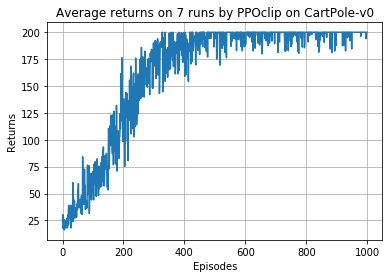

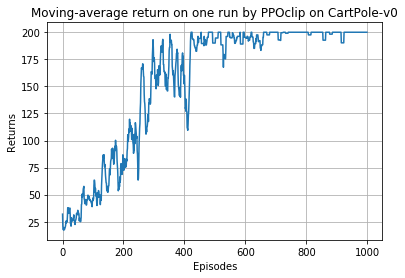

In [51]:
average_list = np.mean(return_lists, axis=0)
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, average_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Average returns on {} runs by PPOclip on {}'.format(len(return_lists),env_name))
plt.grid()
plt.show()

mv_return = moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Moving-average return on one run by PPOclip on {}'.format(env_name))
plt.grid()
plt.show()


In [64]:

total_reward = 0.0
with torch.no_grad():
    for j in range (10):
        total_reward = 0.0  # for 10 consecutive episodes
        for i in range (10): 
            done = False
            observation = env.reset()
            t=0
            while not done:
                t += 1
                if i == 0:
                    env.render()
                action = take_action(actor,observation)
                observation_new, reward, done, info = env.step(action)
                observation = observation_new
                total_reward += reward
                if done:
                    if t <= 199:
                        print("Not success at time step", t, "episode", i, "in group", j)

                    break
        #print("group",j, "reward", total_reward)
        if total_reward < 1950:
            print("Not sucess at group", j, "reward", total_reward)
        else:
            print("Sucess at group",j, "reward", total_reward)
env.close()           



Sucess at group 0 reward 2000.0
Sucess at group 1 reward 2000.0
Sucess at group 2 reward 2000.0
Sucess at group 3 reward 2000.0
Not success at time step 186 episode 8 in group 4
Sucess at group 4 reward 1986.0
Sucess at group 5 reward 2000.0
Not success at time step 177 episode 9 in group 6
Sucess at group 6 reward 1977.0
Sucess at group 7 reward 2000.0
Not success at time step 84 episode 3 in group 8
Not sucess at group 8 reward 1884.0
Sucess at group 9 reward 2000.0
